In [1]:
import pandas as pd
import json
import uuid
import ast # 用于处理 SEntFiN 中复杂的字符串格式

def create_row():
    """创建一个符合 8 字段 Schema 的空字典"""
    return {
        "uid": None, "dataset": None, "task_type": None, "text": None,
        "label": None, "target": None, "market_label": None, "split": "unassigned"
    }

def clean_text(text):
    """文本轻标准化：去除换行、多余空格；空值返回 None"""
    if pd.isna(text):
        return None
    text = " ".join(str(text).split())
    # 空字符串也返回 None
    return text if text else None

In [2]:
def load_fpb(path):
    # FPB 原始格式无表头：[sentiment, text]
    # 使用 names 显式指定，确保映射到正确的列
    df = pd.read_csv(path, encoding='latin-1', names=['label_orig', 'text_orig'])
    rows = []
    for idx, r in df.iterrows():
        row = create_row()
        row.update({
            "uid": f"fpb_{idx:05d}",
            "dataset": "fpb",
            "task_type": "sentence_semantic",
            "text": clean_text(r['text_orig']), # 映射到 text
            "label": str(r['label_orig']).strip().lower(),
            "split": "train"
        })
        rows.append(row)
    return rows

In [3]:
def load_sentfin(path):
    df = pd.read_csv(path)
    rows = []
    parse_errors = []  # 错误统计
    for idx, r in df.iterrows():
        try:
            decision_dict = ast.literal_eval(r['Decisions'])
            # 校验是否为合法非空 dict
            if not isinstance(decision_dict, dict) or not decision_dict:
                parse_errors.append((idx, "empty_or_invalid_dict"))
                continue
            for ent, lab in decision_dict.items():
                row = create_row()
                row.update({
                    "uid": f"sentfin_{idx:05d}_{len(rows):03d}",
                    "dataset": "sentfin",
                    "task_type": "target_semantic",
                    "text": clean_text(r['Title']),
                    "target": ent,
                    "label": str(lab).strip().lower(),
                    "split": "train"
                })
                rows.append(row)
        except Exception as e:
            parse_errors.append((idx, str(e)))
            continue
    # 打印错误行数
    if parse_errors:
        print(f"[WARN] sentfin: {len(parse_errors)} rows failed to parse Decisions")
    return rows

In [4]:
def load_finentity(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for entry in data:
        for ann in entry.get('annotations', []):
            row = create_row()
            row.update({
                "uid": f"finent_{len(rows):06d}",
                "dataset": "finentity",
                "task_type": "target_semantic",
                "text": clean_text(entry.get('content', '')),
                "target": ann.get('value'),
                "label": str(ann.get('label', '')).lower(),
                "split": "train"
            })
            rows.append(row)
    return rows

In [5]:
def load_finmarba(path):
    df = pd.read_csv(path)
    rows = []
    for idx, r in df.iterrows():
        row = create_row()
        row.update({
            "uid": f"finmarba_{idx:05d}",
            "dataset": "finmarba",
            "task_type": "market_aux",
            "text": clean_text(r['Title']),
            # market_label 标准化
            "market_label": str(r['Sentiment']).strip().lower() if pd.notna(r['Sentiment']) else None,
            "label": None,
            "target": None,  # Bug4：禁止塞入 Tickers
            "split": "train"
        })
        rows.append(row)
    return rows

In [6]:
def main_integration():
    all_rows = []
    print("正在加载数据集...")
    all_rows.extend(load_fpb('all-data.csv'))
    all_rows.extend(load_sentfin('SEntFiN-v1.1.csv'))
    all_rows.extend(load_finentity('FinEntity.json'))
    all_rows.extend(load_finmarba('FinMarBa.csv'))

    if not all_rows:
        print("错误：未加载到任何数据，请检查文件名。")
        return

    final_df = pd.DataFrame(all_rows)
    print("确认统一 Schema 列名：", final_df.columns.tolist())

    # ===================== 合法性过滤 =====================
    before_filter = len(final_df)
    # 1. 过滤空文本
    final_df = final_df[final_df['text'].notna() & (final_df['text'] != '')]
    # 2. 过滤 sentence/target 任务缺标签
    mask_label = (final_df['task_type'].isin(['sentence_semantic', 'target_semantic'])) & (final_df['label'].isna())
    final_df = final_df[~mask_label]
    # 3. 过滤 target 任务缺 target
    mask_target = (final_df['task_type'] == 'target_semantic') & (final_df['target'].isna())
    final_df = final_df[~mask_target]
    print(f"[OK] 合法性过滤: {before_filter} → {len(final_df)} (丢弃 {before_filter - len(final_df)})")

    # ===================== 保存去重前原始数据 =====================
    final_df.to_json("integrated_raw.jsonl", orient="records", lines=True, force_ascii=False)
    print(f"[OK] integrated_raw.jsonl 已保存: {len(final_df)} 行")

    # 执行分类去重
    results = []

    # 1. 句子级去重
    df_sent = final_df[final_df['task_type'] == 'sentence_semantic']
    if not df_sent.empty:
        results.append(df_sent.drop_duplicates(subset=['text', 'label']))

    # 2. 实体级去重 (Text + Target + Label)
    df_target = final_df[final_df['task_type'] == 'target_semantic']
    if not df_target.empty:
        results.append(df_target.drop_duplicates(subset=['text', 'target', 'label']))

    # 3. 市场级去重 (Text + Market_Label)
    df_market = final_df[final_df['task_type'] == 'market_aux']
    if not df_market.empty:
        results.append(df_market.drop_duplicates(subset=['text', 'market_label']))

    # 合并清洗后的结果
    cleaned_df = pd.concat(results)

    # 导出为 JSONL
    cleaned_df.to_json("integrated_financial_dataset.jsonl", orient="records", lines=True, force_ascii=False)
    print(f"整合完成！原始总数: {len(final_df)} → 去重后: {len(cleaned_df)}")

if __name__ == "__main__":
    main_integration()

正在加载数据集...
确认统一 Schema 列名： ['uid', 'dataset', 'task_type', 'text', 'label', 'target', 'market_label', 'split']
[OK] 合法性过滤: 29528 → 29528 (丢弃 0)
[OK] integrated_raw.jsonl 已保存: 29528 行
整合完成！原始总数: 29528 → 去重后: 29300


###EDA

In [11]:
# 长度过滤：
df = pd.read_json("integrated_financial_dataset.jsonl", lines=True)
df = df[df['text'].str.len() >= 10].copy()
print(f"长度过滤后剩余: {len(df)}")

长度过滤后剩余: 29299


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取去重前后两份文件
df_raw = pd.read_json("integrated_raw.jsonl", lines=True)

print("去重前行数：", len(df_raw))
print("去重后行数：", len(df))
print("去重删除：", len(df_raw) - len(df))

# 查看前5行数据
print("--- 数据预览 ---")
display(df.head())

去重前行数： 29528
去重后行数： 29299
去重删除： 229
--- 数据预览 ---


,uid,dataset,task_type,text,label,target,market_label,split
0,fpb_00000,fpb,sentence_semantic,"According to Gran , the company has no plans t...",neutral,None,None,train
1,fpb_00001,fpb,sentence_semantic,Technopolis plans to develop in stages an area...,neutral,None,None,train
2,fpb_00002,fpb,sentence_semantic,The international electronic industry company ...,negative,None,None,train
3,fpb_00003,fpb,sentence_semantic,With the new production plant the company woul...,positive,None,None,train
4,fpb_00004,fpb,sentence_semantic,According to the company 's updated strategy f...,positive,None,None,train


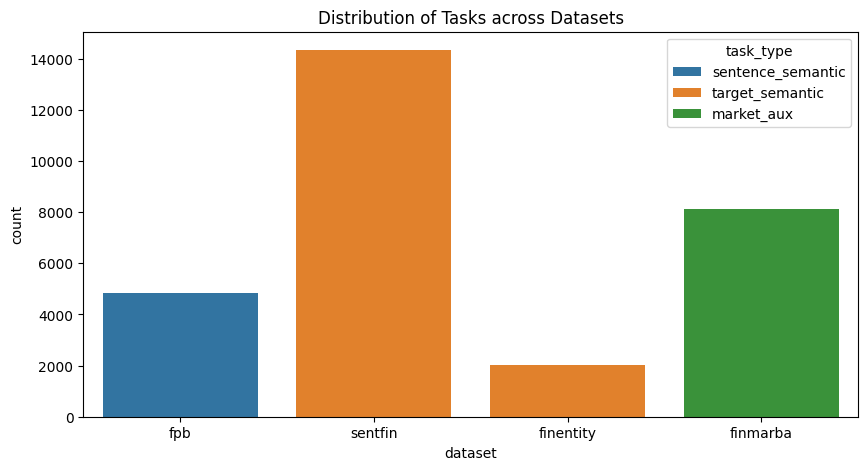

In [13]:
# 各数据集可视化分布
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='dataset', hue='task_type')
plt.title("Distribution of Tasks across Datasets")
plt.show()

In [14]:
# 任务类型分布
print("\n--- 任务类型分布 ---")
print(df['task_type'].value_counts())

print("\n--- 数据集×任务类型分布 ---")
print(df.groupby(['dataset', 'task_type']).size())

print("\n--- label 分布（含空值）---")
print(df['label'].value_counts(dropna=False))

print("\n--- market_label 分布（含空值）---")
print(df['market_label'].value_counts(dropna=False))


--- 任务类型分布 ---
task_type
target_semantic      16339
market_aux            8121
sentence_semantic     4839
Name: count, dtype: int64

--- 数据集×任务类型分布 ---
dataset    task_type        
finentity  target_semantic       2003
finmarba   market_aux            8121
fpb        sentence_semantic     4839
sentfin    target_semantic      14336
dtype: int64

--- label 分布（含空值）---
label
neutral     9383
None        8121
positive    6902
negative    4893
Name: count, dtype: int64

--- market_label 分布（含空值）---
market_label
None                                   21178
{'spy': 1}                               394
{'^gspc': 1}                             383
{'spy': 0}                               352
{'^gspc': 0}                             303
                                       ...  
{'hg=f': 1, 'cl=f': 0}                     1
{'ewq': 0, 'ewk': 0}                       1
{'hd': 1, 'ibm': -1}                       1
{'^tnx': -1, 'uup': 1, '^stoxx': 0}        1
{'^gspc': -1, '^stoxx': 0}             


--- 实体覆盖度 Top10 ---
target
Nifty      419
Sebi       319
Sensex     280
Infosys    131
Gold       121
BSE        106
Rupee       92
RBI         89
NSE         83
rupee       82
Name: count, dtype: int64

--- 文本长度统计（按任务类型）---
                     count        mean        std   min   25%    50%    75%  \
task_type                                                                     
market_aux          8121.0   59.653368  12.676951  23.0  51.0   59.0   67.0   
sentence_semantic   4839.0  128.092581  56.393066  11.0  84.0  119.0  163.0   
target_semantic    16339.0   81.677275  65.257373  18.0  51.0   61.0   76.0   

                     max  
task_type                 
market_aux         150.0  
sentence_semantic  315.0  
target_semantic    580.0  


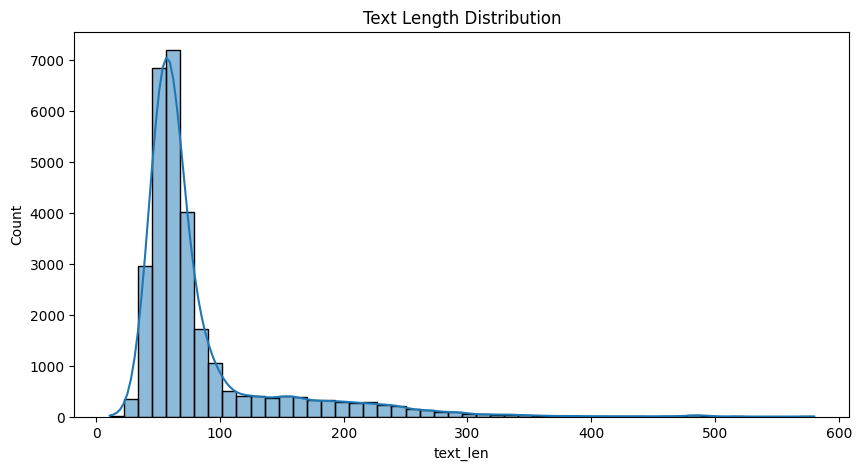

In [15]:
# 实体 Top10
target_data = df[df['task_type'] == 'target_semantic']
print("\n--- 实体覆盖度 Top10 ---")
print(target_data['target'].value_counts().head(10))

# 文本长度按任务类型分组统计
df['text_len'] = df['text'].str.len()
print("\n--- 文本长度统计（按任务类型）---")
print(df.groupby('task_type')['text_len'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Text Length Distribution")
plt.show()

In [16]:
# 空值统计
print("\n--- 各字段空值数 ---")
print(df.isnull().sum())


--- 各字段空值数 ---
uid                 0
dataset             0
task_type           0
text                0
label            8121
target          12960
market_label    21178
split               0
text_len            0
dtype: int64


###保存最终预处理后数据

In [17]:
df_clean = df.copy()
print(f"预处理最终样本数: {len(df_clean)}")

#最后保存最终文件
df_clean.to_json("final_preprocessed.jsonl", orient="records", lines=True, force_ascii=False)

预处理最终样本数: 29299
